<a href="https://colab.research.google.com/github/carollinemelloo/ProcessamentoDeImagens/blob/main/Portfolio02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
arquivo = files.upload()

Saving escura.jpeg to escura.jpeg
Saving clara.jpeg to clara.jpeg
Saving regular.jpeg to regular.jpeg


In [4]:
img_regular = cv2.imread('regular.jpeg')
img_clara = cv2.imread('clara.jpeg')
img_escura = cv2.imread('escura.jpeg')

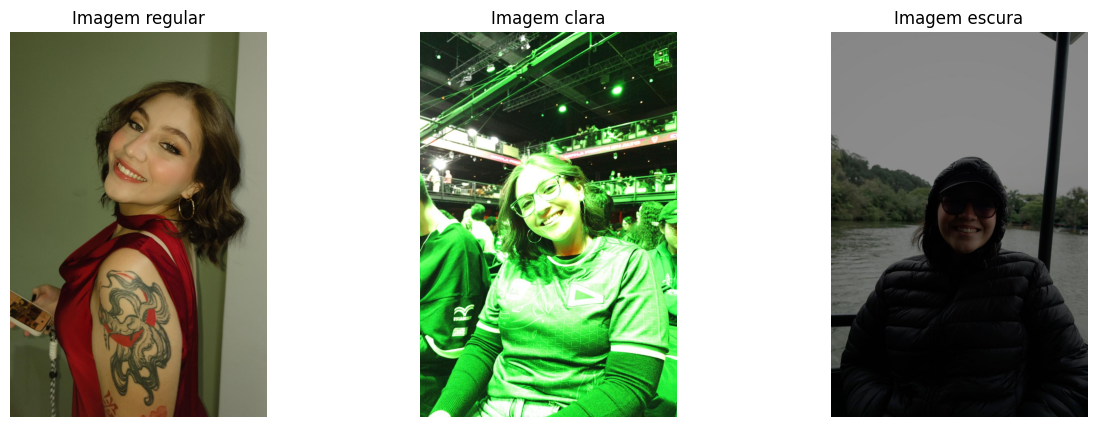

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_regular, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagem regular")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_clara, cv2.COLOR_BGR2RGB))
axes[1].set_title("Imagem clara")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_escura, cv2.COLOR_BGR2RGB))
axes[2].set_title("Imagem escura")
axes[2].axis("off")

plt.show()

In [13]:
def calc_hist(img):
    img_vetor = img.ravel()
    hist_vetor = np.zeros(256, dtype=np.int64)

    for px in img_vetor:
        hist_vetor[px] += 1

    return hist_vetor


def expandir_contraste(img, L, H):
    img_float = img.astype(np.float32)
    img_float = np.clip(img_float, L, H)
    img_expandida = ((img_float - L) / (H - L)) * 255
    return img_expandida.astype(np.uint8)


def equalizar(img):
    return cv2.equalizeHist(img)


def corrigir_gamma(img, gamma):
    tabela = np.array([
        ((i / 255.0) ** gamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    return cv2.LUT(img, tabela)


def mostrar_resultado(original, resultado, titulo_original, titulo_resultado):
    hist_original = calc_hist(original)
    hist_resultado = calc_hist(resultado)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title(titulo_original)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(resultado, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(titulo_resultado)
    axes[0, 1].axis('off')

    axes[1, 0].bar(range(256), hist_original)
    axes[1, 0].set_title("Histograma - Antes")
    axes[1, 0].set_xlim(0, 255)

    axes[1, 1].bar(range(256), hist_resultado)
    axes[1, 1].set_title("Histograma - Depois")
    axes[1, 1].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

In [6]:
gray_regular = cv2.cvtColor(img_regular, cv2.COLOR_BGR2GRAY)
gray_clara = cv2.cvtColor(img_clara, cv2.COLOR_BGR2GRAY)
gray_escura = cv2.cvtColor(img_escura, cv2.COLOR_BGR2GRAY)

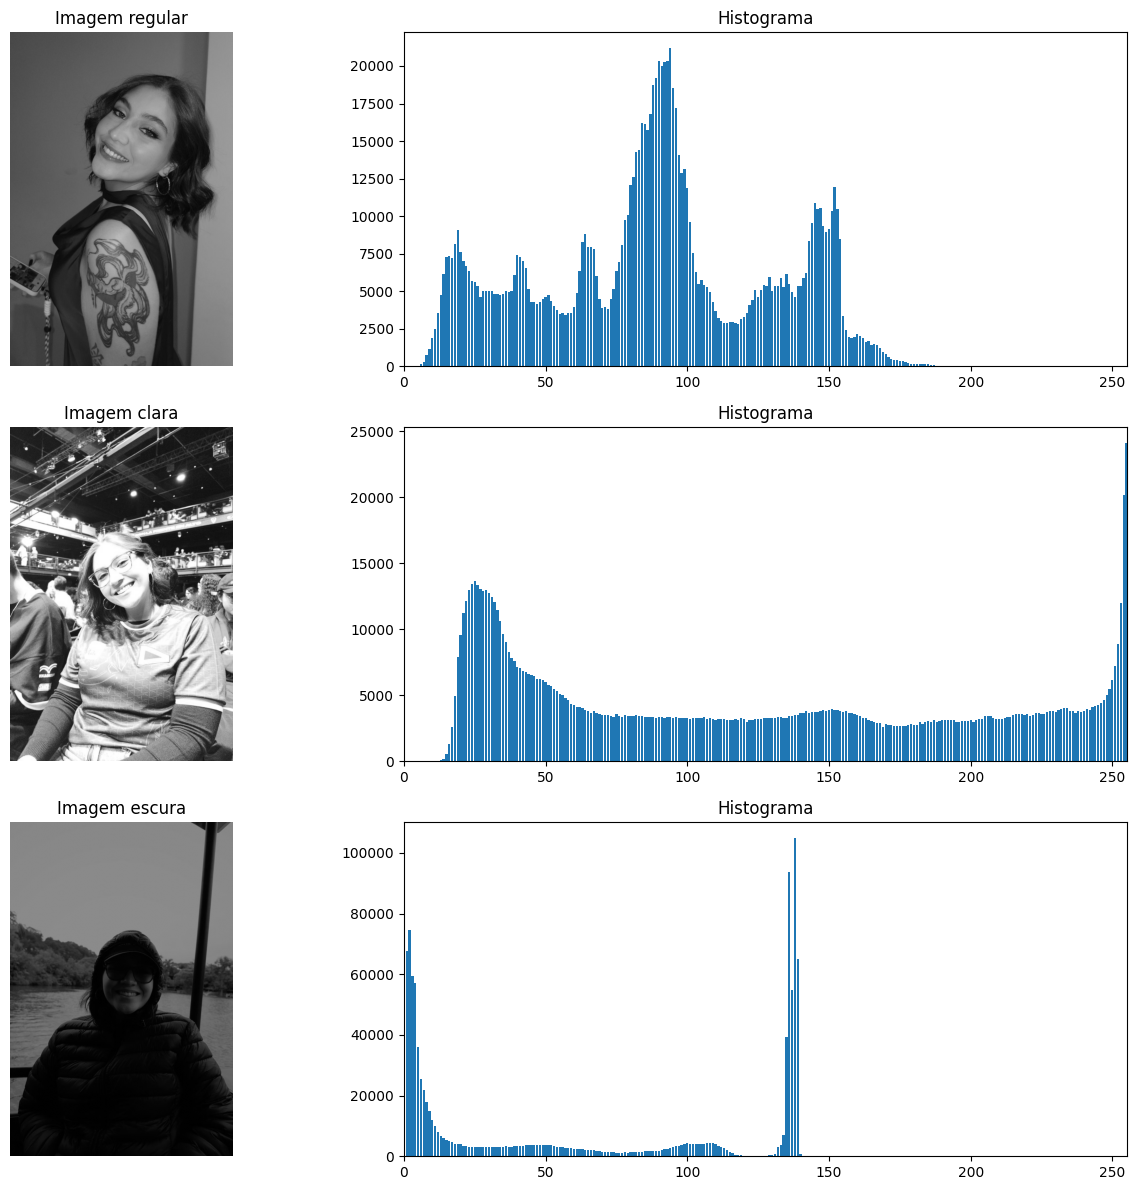

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

imagens = [
    (gray_regular, "Imagem regular"),
    (gray_clara, "Imagem clara"),
    (gray_escura, "Imagem escura")
]

for i, (img, titulo) in enumerate(imagens):
    axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(titulo)
    axes[i, 0].axis('off')

    hist = calc_hist(img)
    axes[i, 1].bar(range(256), hist)
    axes[i, 1].set_title("Histograma")
    axes[i, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

# Diagnóstico baseando-se nos histogramas
**Imagem regular**: As intensidades estão distribuídas principalmente entre aproximadamente 20 e 180, com maior concentração na faixa de 70 a 160. Isso indica uma imagem bem exposta, com boa presença de tons escuros, médios e claros.

**Imagem clara**: As intensidades estão bastante concentradas na região alta, principalmente entre 200 e 255, com uma grande quantidade de pixels próximos de 255. Isso indica excesso de luminosidade e presença de áreas muito claras ou saturadas.

**Imagem escura**: As intensidades estão concentradas principalmente nas baixas intensidades, entre 0 e 30, embora também exista um pico na região de aproximadamente 130 a 140. Isso indica que grande parte da imagem está muito escura, com pouca informação nas regiões de tons médios e claros.

# Fotos Corrigidas e Justificativas

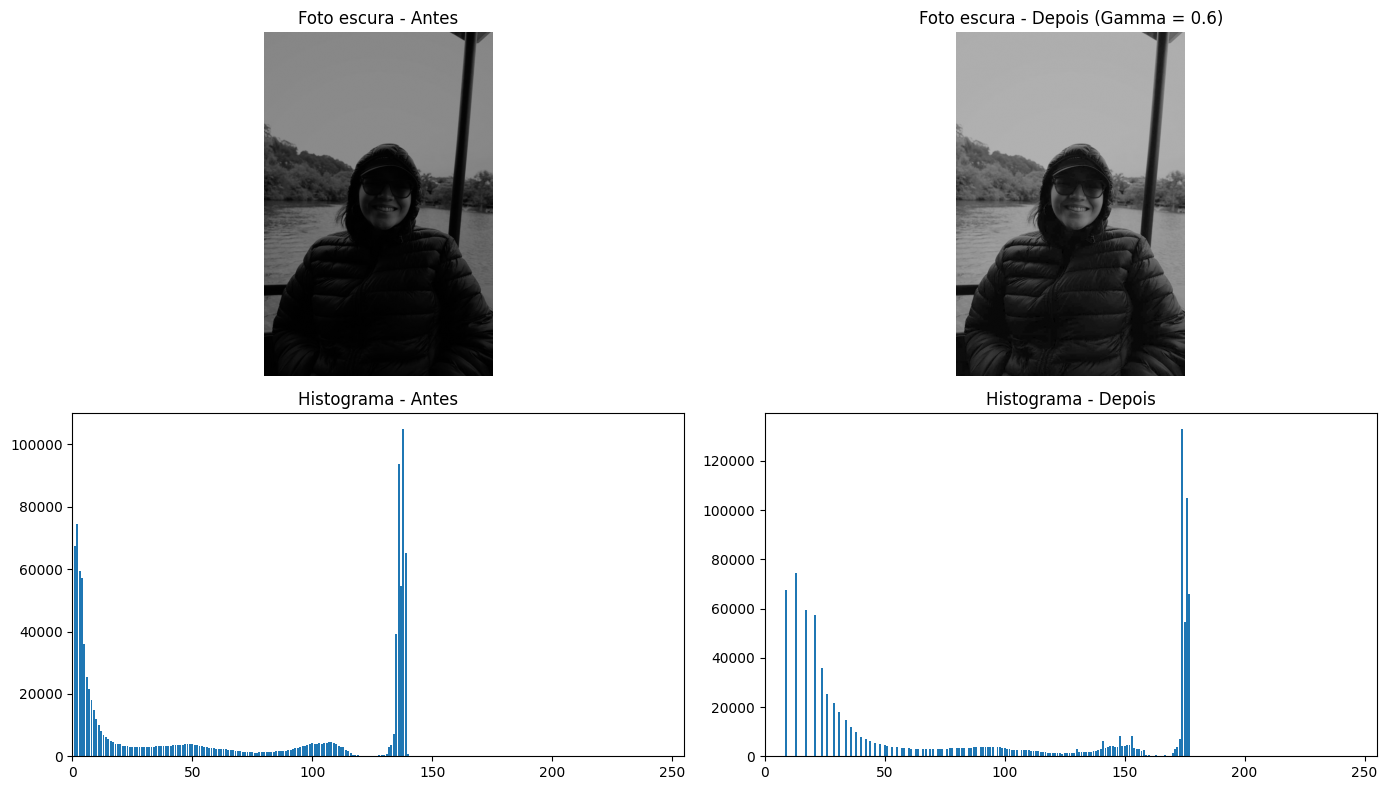

In [10]:
escura_corrigida = corrigir_gamma(gray_escura, 0.6)

mostrar_resultado(
    gray_escura,
    escura_corrigida,
    "Foto escura - Antes",
    "Foto escura - Depois (Gamma = 0.6)"
)

# Justificativa da Imagem Escura
Foi utilizada a correção de gamma com γ = 0,6 porque a imagem apresenta predominância de regiões escuras, com o histograma concentrado principalmente nas baixas intensidades. Como valores de gamma menores que 1 aumentam a luminosidade dos tons mais escuros, a operação foi escolhida para realçar os detalhes da pessoa e do ambiente que estavam pouco visíveis na imagem original.

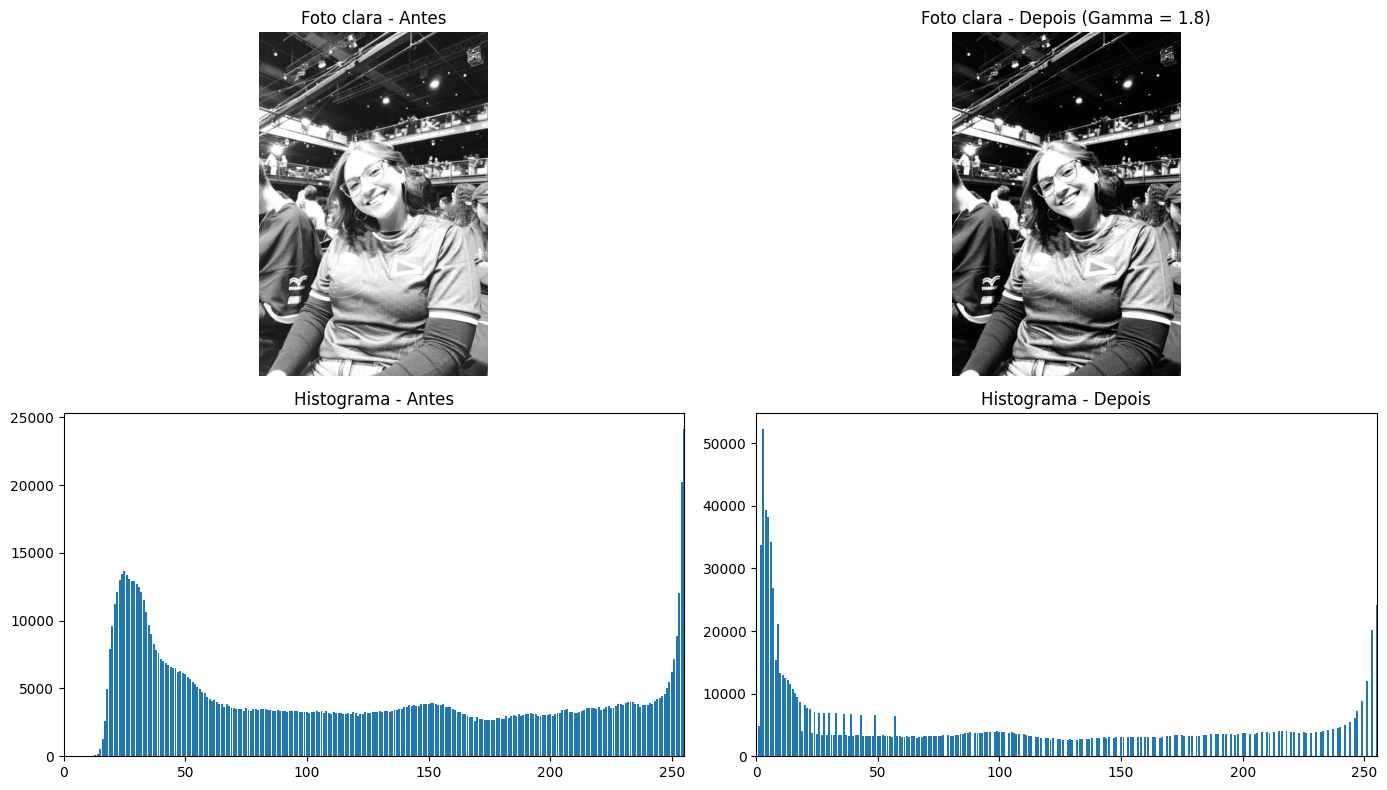

In [11]:
clara_corrigida = corrigir_gamma(gray_clara, 1.8)

mostrar_resultado(
    gray_clara,
    clara_corrigida,
    "Foto clara - Antes",
    "Foto clara - Depois (Gamma = 1.8)"
)

# Justificativa da Imagem Clara
Foi utilizada a correção de gamma com γ = 1,8 porque a imagem apresenta regiões com intensidade muito elevada, incluindo uma grande concentração de pixels próximos ao branco. Como valores de gamma maiores que 1 reduzem as intensidades, a operação foi escolhida para diminuir o excesso de luminosidade e melhorar a visualização dos detalhes presentes nas regiões mais claras da fotografia.

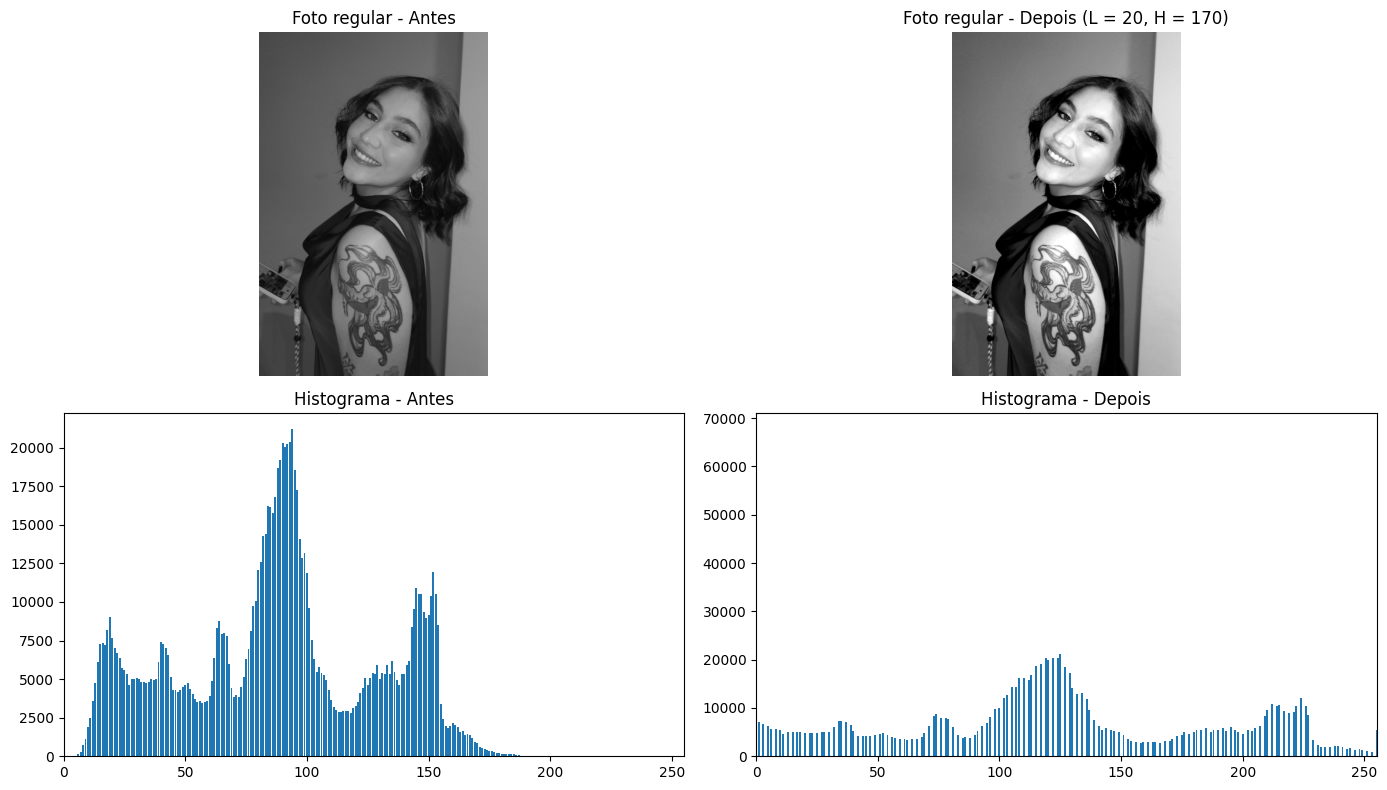

In [16]:
regular_corrigida = expandir_contraste(gray_regular, 20, 170)

mostrar_resultado(
    gray_regular,
    regular_corrigida,
    "Foto regular - Antes",
    "Foto regular - Depois (L = 20, H = 170)"
)

# Justificativa da Imagem Regular
Foi utilizada a expansão de contraste com L = 20 e H = 170 porque a imagem já apresenta uma exposição adequada, com os pixels concentrados principalmente em uma faixa intermediária de intensidades. Inicialmente, foi realizado um teste com outros valores de L e H (L = 10 e H = 245), porém o resultado apresentou uma alteração excessiva no contraste e acabou piorando a aparência da imagem. Por isso, foram escolhidos os parâmetros L = 20 e H = 170, que proporcionaram uma melhoria mais equilibrada, aumentando o contraste sem comprometer significativamente a qualidade da fotografia.

# **Em qual das três imagens a operação fez menos diferença? Por quê?**

A operação fez menos diferença na imagem regular, pois ela já apresentava uma exposição adequada e uma distribuição relativamente equilibrada das intensidades no histograma. Por isso, a expansão de contraste com L = 20 e H = 170 provocou apenas uma alteração moderada na imagem, enquanto as fotos clara e escura precisaram de correções mais perceptíveis para compensar o excesso ou a falta de luminosidade.